# Análisis cualitativo del modelo entrenado con respecto al modelo base

In [1]:
#Imports
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForImageTextToText, AutoProcessor
from peft import PeftModel
from PIL import Image


## Carga del modelo base de MedGemma

In [4]:
base_model_id = "google/medgemma-4b-it"
from transformers import BitsAndBytesConfig



def cargar_modelo_base(model_id:str,online:bool=True,cache_dir:str=""):
   


    model_kwargs = dict(
        attn_implementation="eager",
        
        device_map="auto",
        torch_dtype="auto"
    )
    
    bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    llm_int8_enable_fp32_cpu_offload=True # ESTO ES LA CLAVE
)

    print("\tCargando el modelo base")
    if online :
      model=AutoModelForImageTextToText.from_pretrained(base_model_id)  
    else:
        #model = AutoModelForImageTextToText.from_pretrained(cache_dir,local_files_only=True,quantization_config=bnb_config, **model_kwargs)
        #sin quantificacion
        model = AutoModelForImageTextToText.from_pretrained(cache_dir,local_files_only=True, **model_kwargs)
    print("\tModel base cargado")

    print("\tCarga del processor base")
    
    if online: 
        processor = AutoProcessor.from_pretrained(base_model_id)
    else:
        processor = AutoProcessor.from_pretrained(cache_dir,local_files_only=True,)
    print("\tProcessor base cargado")

    return model,processor


In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1650 Ti


In [6]:
base_model_id = "google/medgemma-4b-it"
cache_dir="D:/modelos/MedGemma/medgemma"
base_model, base_processor=cargar_modelo_base(base_model_id, online=False,cache_dir=cache_dir)

	Cargando el modelo base


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


	Model base cargado
	Carga del processor base
	Processor base cargado


## Carga del modelo obtenido con funetunning

In [7]:
def cargar_modelo_checkpoint(base_model,path_checkpoint:str):
    print("\tCargando el modelo ft")
    ft_model=model = PeftModel.from_pretrained(base_model, path_checkpoint) #No seguro que sea así
    print("\tModel ft cargado")
    ft_processor = AutoProcessor.from_pretrained(base_model_id)
    print("\tProcessor ft cargado")
    
    return ft_model, ft_processor

In [8]:
path_checkpoint="D:/modelos/MedTrinity25_demo/FT1/checkpoint-2273"   #ruta a donde están guardado el checkpoint que vamos a usar


ft_model, ft_processor = cargar_modelo_checkpoint(base_model=base_model,path_checkpoint=path_checkpoint)

	Cargando el modelo ft


c:\Users\pedro\anaconda3\envs\pytorch_env\Lib\site-packages\peft\tuners\tuners_utils.py:1222: UserWarning: Model has `tie_word_embeddings=True` and a tied layer is part of the adapter, but `ensure_weight_tying` is not set to True. This can lead to complications, for example when merging the adapter or converting your model to formats other than safetensors. Check the discussion here: https://github.com/huggingface/peft/issues/2777
  warnings.warn(msg)


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.25 GiB. GPU 0 has a total capacity of 4.00 GiB of which 0 bytes is free. Of the allocated memory 6.36 GiB is allocated by PyTorch, and 36.71 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

## Diseño del Prompt

Usamos el mismo que el usado en el entrenamiento

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            
            {"type": "text",
             "text": "Examine this axial brain MRI image. Identify any abnormalities, their location, and their characteristics, only if they are present."}
        ]
    }
]

prompt_template= base_processor.apply_chat_template(messages,add_generation_prompt=True) #Para que sepa que ahora le toca a él



## Carga la imagen a inferir

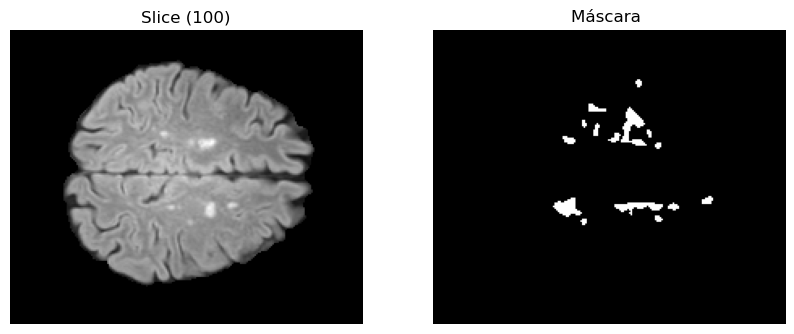

In [ ]:
SAMPLES_DIR= Image.open("/mnt/home/users/tic_163_colab/pedrofdez/fscratch/picasso/dataset/inferences/axial_mri_samples")
mask= Image.open("D:/data/inferencia/esclerosis/mask/1.png")

#Mostramos imagen-máscara

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(image,cmap="gray")
axes[0].set_title("Slice (100)")
axes[0].set_axis_off()

axes[1].imshow(mask,cmap="gray")
axes[1].set_title("Máscara ")
axes[1].set_axis_off()



## Prueba modelo base

Procesamos la información de entrada con el processor base

In [16]:
base_inputs = base_processor(
    text=prompt_template, 
    images=image, 
    return_tensors="pt"
).to("cuda")

Generación de respuesta del modelo

In [17]:
import gc

gc.collect()
torch.cuda.empty_cache()

In [1]:
with torch.no_grad():
    
    output_ids = base_model.generate(
        **base_inputs,
        max_new_tokens=50,   # Suficiente para una descripción detallada
        do_sample=True,       # Permite un poco de fluidez
        temperature=0.1,      # Regula el equilibrio entre precisión técnica y creatividad del modelo. Más cercano a 1, más creativo
        top_p=0.9,            # Ayuda a elegir palabras con sentido médico
        use_cache=True        # Acelera la generación
    )

NameError: name 'torch' is not defined

La respuesta 

In [9]:
#!pip install --upgrade torch torchvision torchaudio
print(torch.__version__)
#!pip install torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 --index-url https://download.pytorch.org/whl/cu124

2.5.1+cu121


Procesamos la información dada para ambos modelos (usamos los dos procesadores de los modelos)

In [ ]:


ft_inputs= ft_processor(text=PROMPT, images=image,return_tensors="pt").to("cuda")

NameError: name 'base_processor' is not defined